# asses the history of runs


In [6]:
import sys
print(sys.executable)


import pandas as pd
%matplotlib inline

import matplotlib
print("backend:", matplotlib.get_backend())
import matplotlib.pyplot as plt

import corner
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np


/home/kandrych/venvs/obriy311/bin/python
backend: module://matplotlib_inline.backend_inline


In [10]:



df=pd.read_csv("/fred/oz061/kandrych/smac/20260611_new_set_edge_no_puffed_budget1/smac_results/trials.csv")
results_dir="/fred/oz061/kandrych/smac/20260611_new_set_edge_no_puffed_budget1/smac_results/after_optimisation/"
Path(results_dir).mkdir(parents=True, exist_ok=True)

exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc'}

param_cols = [c for c in df.columns if c not in exclude]
print(param_cols)

df


['alpha_viscosity', 'zone_1_-gamma_exp', 'zone_1_Rc', 'zone_1_dust_mass', 'zone_1_edge', 'zone_1_flaring_exp', 'zone_1_gas_to_dust', 'zone_1_scale_height', 'zone_1_species_1_amin', 'zone_1_species_1_porosity', 'zone_1_species_1_volume_fraction', 'zone_1_surface_density_exp']


,alpha_viscosity,distance_pc,zone_1_-gamma_exp,zone_1_Rc,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.01000,1220.0,2.616855,164.960172,0.00050,0.249541,1.189453,100.0,4.118354,0.000063,0.635013,0.5,-0.841234,26,123825480,1.1,118.099701,222.324214,1
1,0.10000,1220.0,1.352205,220.067633,0.00050,0.764657,1.636159,100.0,2.051627,0.393521,0.736159,0.3,-0.425073,80,123825480,1.1,142.396317,206.705176,1
2,0.00100,1220.0,0.091303,325.563240,0.00100,1.089397,1.921500,50.0,7.051412,0.000249,0.424547,0.8,-0.372330,120,123825480,1.1,147.893215,146.626039,1
3,0.01000,1220.0,0.922696,260.478855,0.00010,0.051103,1.591636,100.0,5.294534,0.000591,0.029450,0.3,-1.900040,295,123825480,1.1,165.404587,199.536094,1
4,0.01000,1220.0,2.441782,164.960172,0.00050,0.428577,1.189453,100.0,4.833564,0.000015,0.638231,0.7,-0.841234,236,123825480,1.1,170.848982,251.992556,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.00001,1220.0,-2.377199,448.233299,0.00400,0.670382,1.972948,10.0,9.215641,0.000005,0.072326,0.7,-1.426941,455,123825480,1.1,inf,674.227420,2
496,0.00100,1220.0,0.185945,302.683264,0.00400,0.905411,1.303354,50.0,5.673984,0.000002,0.500107,0.3,-0.646695,458,123825480,1.1,inf,210.034327,2
497,0.10000,1220.0,2.764348,412.013404,0.00400,1.195242,1.789498,200.0,9.324829,0.000004,0.168658,0.5,-0.496844,471,123825480,1.1,inf,1171.225136,2
498,0.10000,1220.0,-0.400298,491.444686,0.00001,0.496875,1.131883,200.0,7.353959,0.000005,0.481568,0.3,-0.884349,480,123825480,1.1,inf,201.790593,2


### Best configs table (at max budget)

In [11]:
top = df[df["budget"] == df["budget"].max()].nsmallest(5, "cost")
print("Top 5 max budget trials:")
top
#top.to_csv(results_dir / "top5_maxbudget.csv", index=False)



Top 5 max budget trials:


,alpha_viscosity,distance_pc,zone_1_-gamma_exp,zone_1_Rc,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time,status
0,0.010,1220.0,2.616855,164.960172,0.0005,0.249541,1.189453,100.0,4.118354,0.000063,0.635013,0.5,-0.841234,26,123825480,1.1,118.099701,222.324214,1
1,0.100,1220.0,1.352205,220.067633,0.0005,0.764657,1.636159,100.0,2.051627,0.393521,0.736159,0.3,-0.425073,80,123825480,1.1,142.396317,206.705176,1
2,0.001,1220.0,0.091303,325.563240,0.0010,1.089397,1.921500,50.0,7.051412,0.000249,0.424547,0.8,-0.372330,120,123825480,1.1,147.893215,146.626039,1
3,0.010,1220.0,0.922696,260.478855,0.0001,0.051103,1.591636,100.0,5.294534,0.000591,0.029450,0.3,-1.900040,295,123825480,1.1,165.404587,199.536094,1
4,0.010,1220.0,2.441782,164.960172,0.0005,0.428577,1.189453,100.0,4.833564,0.000015,0.638231,0.7,-0.841234,236,123825480,1.1,170.848982,251.992556,1


### Crashed runs inspection

1e+99


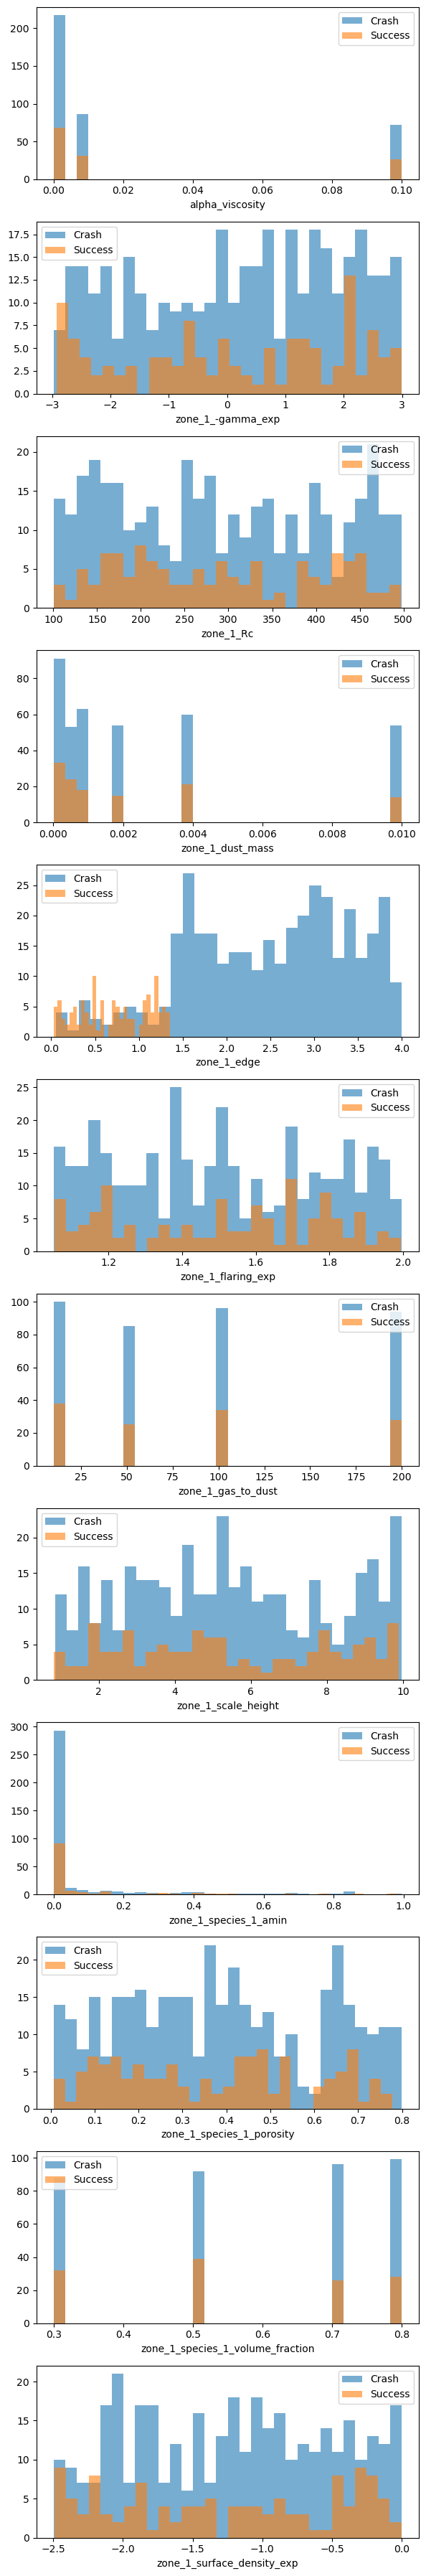

In [25]:
df["status"] = np.where((df["cost"]==1e99) | (df["cost"]==df["cost"].max()), "Crashed", "Success")
df.loc[df['cost'] == df['cost'].max(), 'cost'] = 1e99
print(max(df['cost']))




crashed_trials=df[df["status"]=="Crashed"]
successful_trials=df[df["status"]=="Success"]




#crashed_trials.describe()


crashed_trials.describe().T.join(
   successful_trials.describe().T,
   lsuffix="_crashed",
   rsuffix="_successful"
)






fig, axes = plt.subplots(len(param_cols), 1,
                        figsize=(6, 3*len(param_cols)))


for ax, p in zip(axes, param_cols):
   ax.hist(df[df["status"]=="Crashed"][p],
           bins=30,
           alpha=0.6,
           label="Crash")
   ax.hist(df[df["status"]=="Success"][p],
           bins=30,
           alpha=0.6,
           label="Success")


   ax.set_xlabel(p)
   ax.legend()


plt.tight_layout()
plt.savefig(results_dir +"Histograms_crashed_vs_successful.png", dpi=150)
plt.show()
plt.close()



### Pairwise sanity checks (parameter vs cost)


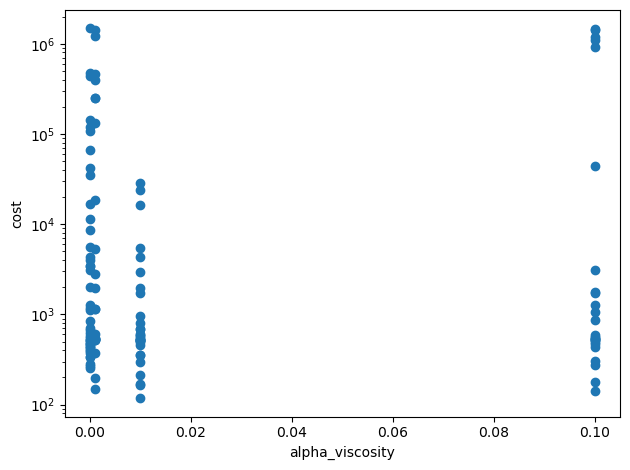

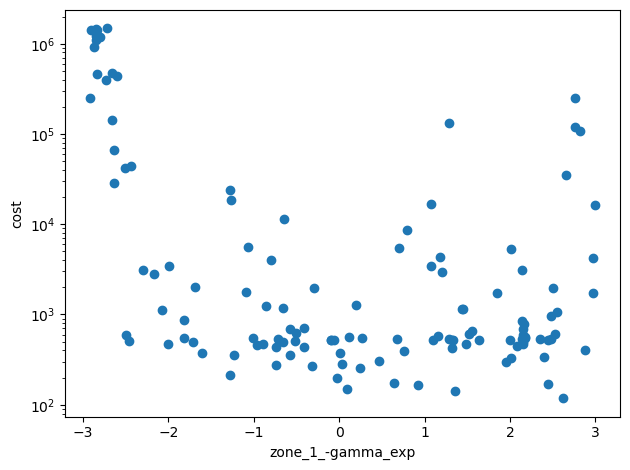

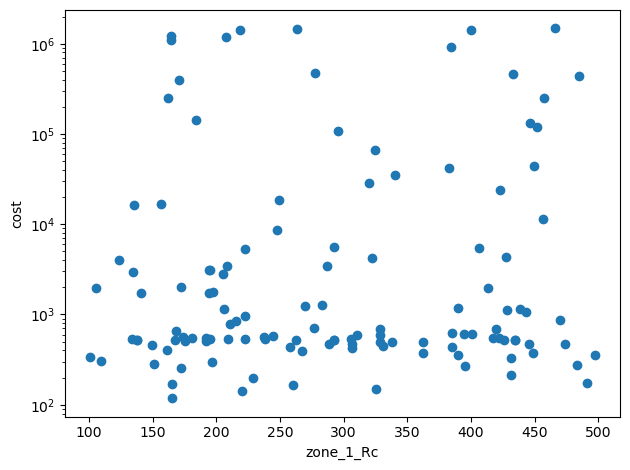

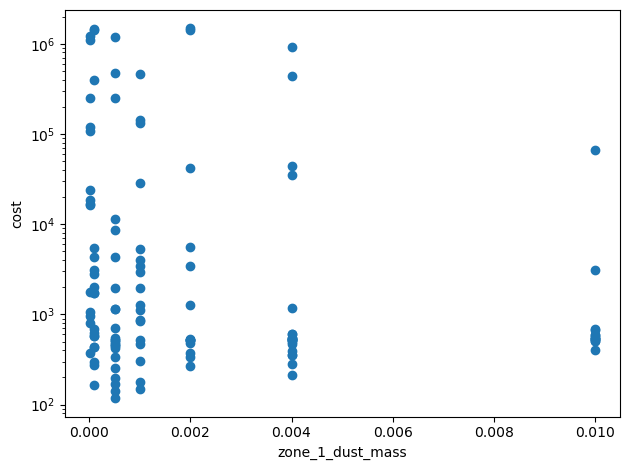

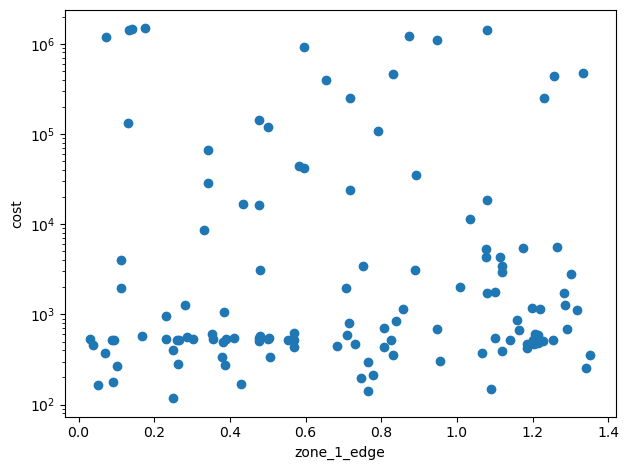

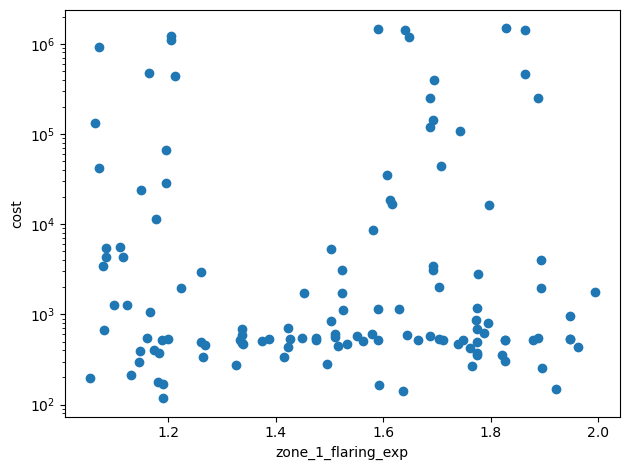

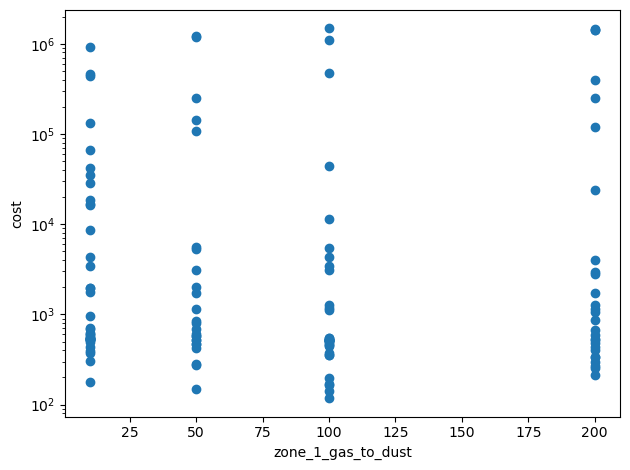

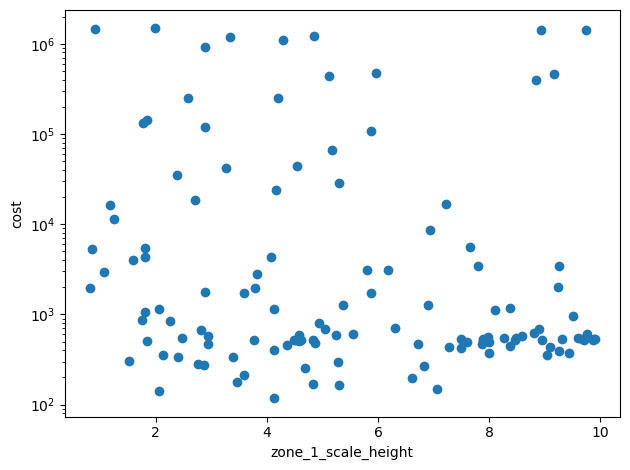

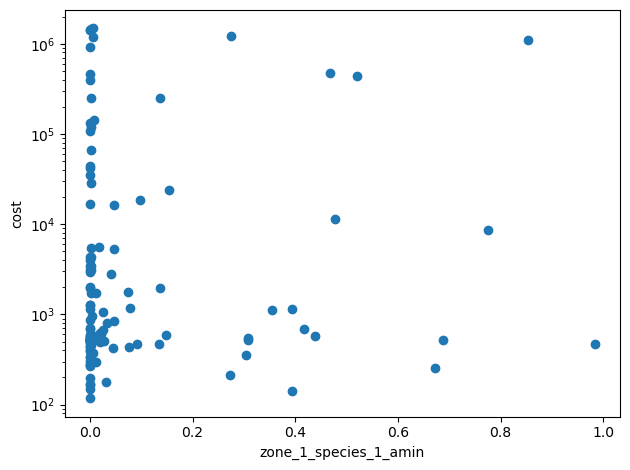

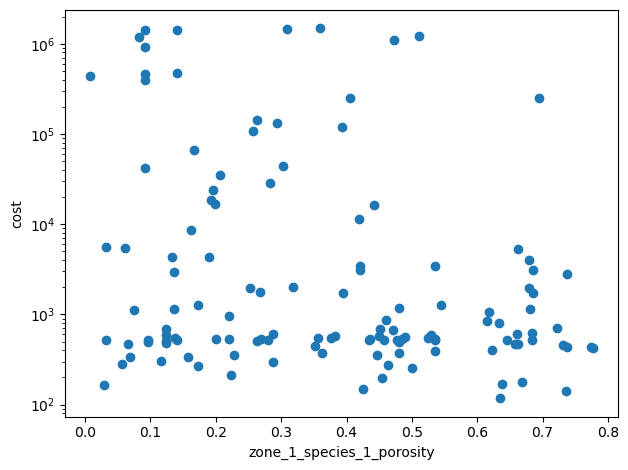

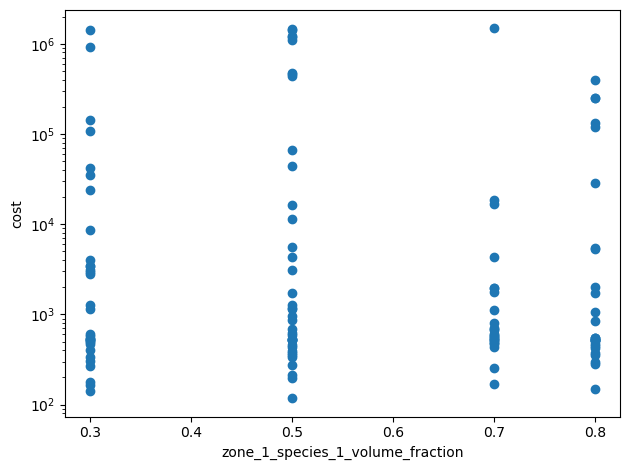

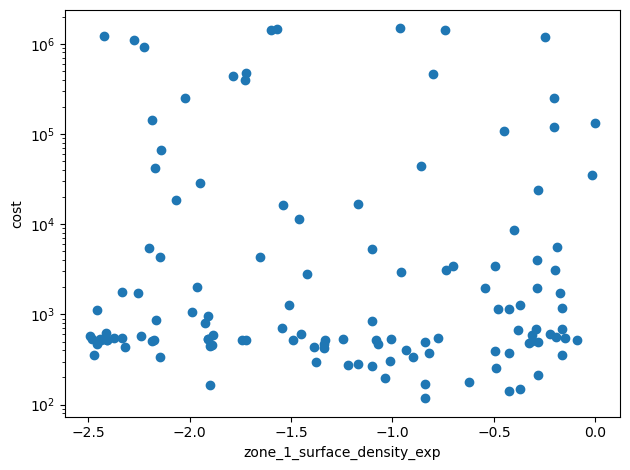

In [14]:


for p in param_cols:  # rename to your actual names
    if p in df.columns:
        plt.figure()
        plt.scatter(successful_trials[p], successful_trials["cost"])
        plt.xlabel(p); plt.ylabel("cost")
        plt.yscale("log")  # often helpful
        plt.tight_layout()
        plt.savefig(results_dir +f"scatter_{p}.png", dpi=150)
        plt.show()
        plt.close()


### Slice by budget (does the story change with fidelity?)

In [17]:
successful_trials.groupby("budget")["cost"].describe()#.to_csv(results_dir / "cost_by_budget.csv")


,count,mean,std,min,25%,50%,75%,max
budget,,,,,,,,
1.1,125.0,107258.744687,322513.669255,118.099701,492.016289,627.556124,5289.476328,1.475290e+06


### Parameter importance (fast, practical)

In [18]:
def binned_medians(successful_trials, param, bins=2):
    s = successful_trials[[param, "cost"]].dropna()
    s["bin"] = pd.qcut(s[param], q=bins, duplicates="drop")
    return s.groupby("bin", observed=True)["cost"].median().sort_values()

for p in ["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]:
    if p in successful_trials.columns:
        bm = binned_medians(successful_trials[successful_trials["budget"] == successful_trials["budget"].max()], p)
        print(f"Binned medians for {p}:")
        print(bm)
        #bm.to_csv(results_dir / f"binned_median_{p}.csv")


Binned medians for zone_1_Rc:
bin
(282.673, 497.304]               606.133615
(100.53999999999999, 282.673]    700.175991
Name: cost, dtype: float64
Binned medians for zone_1_flaring_exp:
bin
(1.0530000000000002, 1.533]    591.793360
(1.533, 1.994]                 740.519927
Name: cost, dtype: float64
Binned medians for zone_1_dust_mass:
bin
(0.001, 0.01]         533.793062
(-0.00099, 0.001]    1147.564801
Name: cost, dtype: float64
Binned medians for zone_1_species_1_porosity:
bin
(0.376, 0.777]       573.280712
(0.00614, 0.376]    1137.717151
Name: cost, dtype: float64


### Clustering of “good” solutions (degeneracies)

In [19]:

percent_of_successful = len(successful_trials)*0.1

good = successful_trials[successful_trials["budget"] == successful_trials["budget"].max()].nsmallest(int(percent_of_successful), "cost")
good.describe()#.to_csv(results_dir / "good5_summary.csv")

,alpha_viscosity,distance_pc,zone_1_-gamma_exp,zone_1_Rc,zone_1_dust_mass,zone_1_edge,zone_1_flaring_exp,zone_1_gas_to_dust,zone_1_scale_height,zone_1_species_1_amin,zone_1_species_1_porosity,zone_1_species_1_volume_fraction,zone_1_surface_density_exp,config_id,seed,budget,cost,time
count,12.000000,12.0,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.0,1.200000e+01,12.000000,12.000000
mean,0.028518,1220.0,0.497900,290.755580,0.001225,0.524041,1.447746,105.000000,4.512569,0.114296,0.416971,0.516667,-0.858358,255.000000,123825480.0,1.100000e+00,200.463425,228.976573
std,0.043320,0.0,1.179154,129.316481,0.001390,0.417878,0.310531,64.173061,1.675782,0.218515,0.242980,0.194625,0.461862,151.179604,0.0,2.319180e-16,56.501478,56.245752
min,0.000010,1220.0,-1.282652,151.269369,0.000100,0.051103,1.053636,10.000000,2.051627,0.000012,0.029450,0.300000,-1.900040,26.000000,123825480.0,1.100000e+00,118.099701,146.626039
25%,0.000775,1220.0,-0.096413,170.596310,0.000500,0.212482,1.187050,50.000000,3.315029,0.000019,0.210938,0.300000,-1.116581,110.000000,123825480.0,1.100000e+00,161.026744,201.267320
50%,0.010000,1220.0,0.165123,244.532309,0.000500,0.407197,1.410576,100.000000,4.404788,0.000393,0.458949,0.500000,-0.841234,280.500000,123825480.0,1.100000e+00,185.831250,222.041654
75%,0.032500,1220.0,1.030073,403.984104,0.001250,0.768116,1.668314,125.000000,5.623248,0.091855,0.635818,0.700000,-0.473511,355.500000,123825480.0,1.100000e+00,259.087340,252.215458
max,0.100000,1220.0,2.616855,491.106938,0.004000,1.340131,1.921500,200.000000,7.051412,0.671988,0.736159,0.800000,-0.283522,495.000000,123825480.0,1.100000e+00,281.889557,328.670869


### Plot

In [21]:
curve = successful_trials.groupby(["config_id", "budget"])["cost"].min().reset_index()
curve#.to_csv(results_dir / "learning_curves.csv", index=False)


,config_id,budget,cost
0,1,1.1,591.793360
1,4,1.1,508.262968
2,25,1.1,11355.771928
3,26,1.1,118.099701
4,34,1.1,534.732542
...,...,...,...
120,491,1.1,1255.816387
121,492,1.1,533.958572
122,494,1.1,553.145944
123,495,1.1,176.178018


## For the cornerplot


SMAC does not give a true posterior.
This corner plot represents a high-likelihood region sampled by Bayesian optimisation, not an MCMC posterior.
So... distribution of high-performing models:

In [22]:
# Restrict to highest fidelity
df_max = successful_trials[successful_trials["budget"] == successful_trials["budget"].max()].copy()

# Drop failed / NaN
df_max = df_max.dropna(subset=["cost"])

# Optional: keep only the best 30% of trials
q = 0.9
cost_cut = df_max["cost"].quantile(q)
df_sel = df_max[df_max["cost"] <= cost_cut]


In [23]:
exclude = {"config_id", "seed", "budget", "cost", "time", "status", 
           'distance_pc'}

param_cols = [c for c in df_sel.columns if c not in exclude]
param_cols


['alpha_viscosity',
 'zone_1_-gamma_exp',
 'zone_1_Rc',
 'zone_1_dust_mass',
 'zone_1_edge',
 'zone_1_flaring_exp',
 'zone_1_gas_to_dust',
 'zone_1_scale_height',
 'zone_1_species_1_amin',
 'zone_1_species_1_porosity',
 'zone_1_species_1_volume_fraction',
 'zone_1_surface_density_exp']

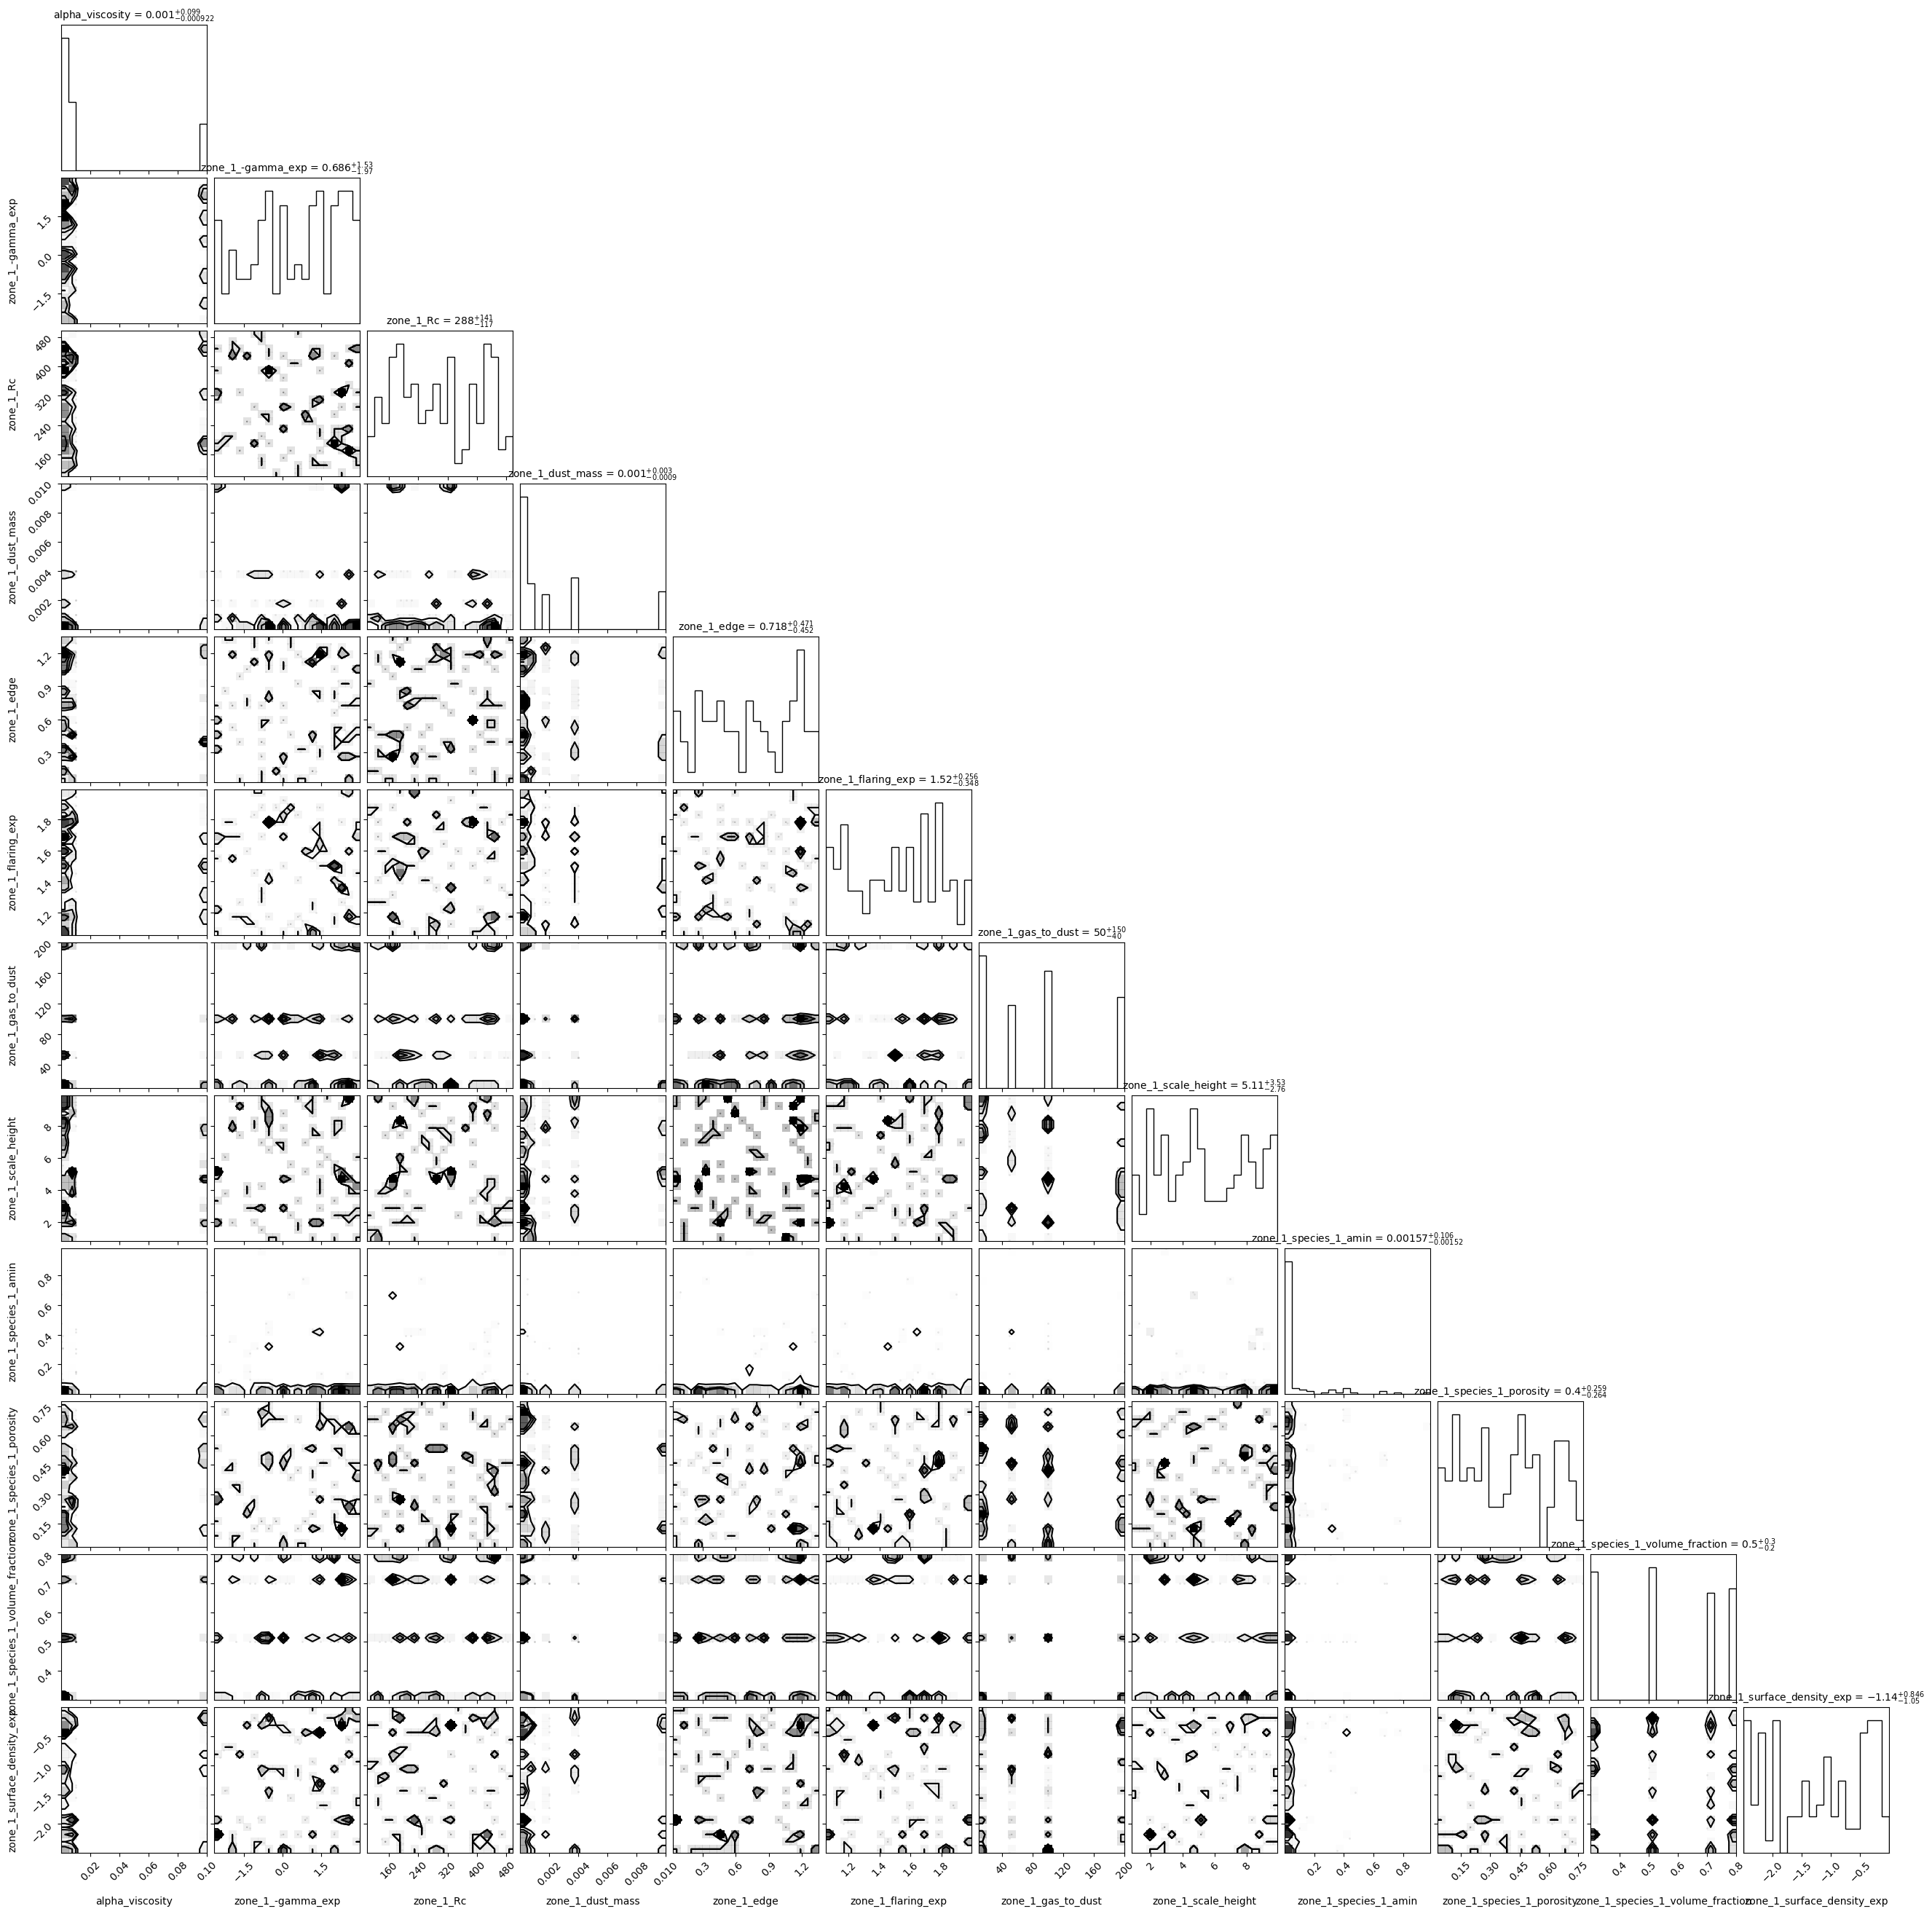

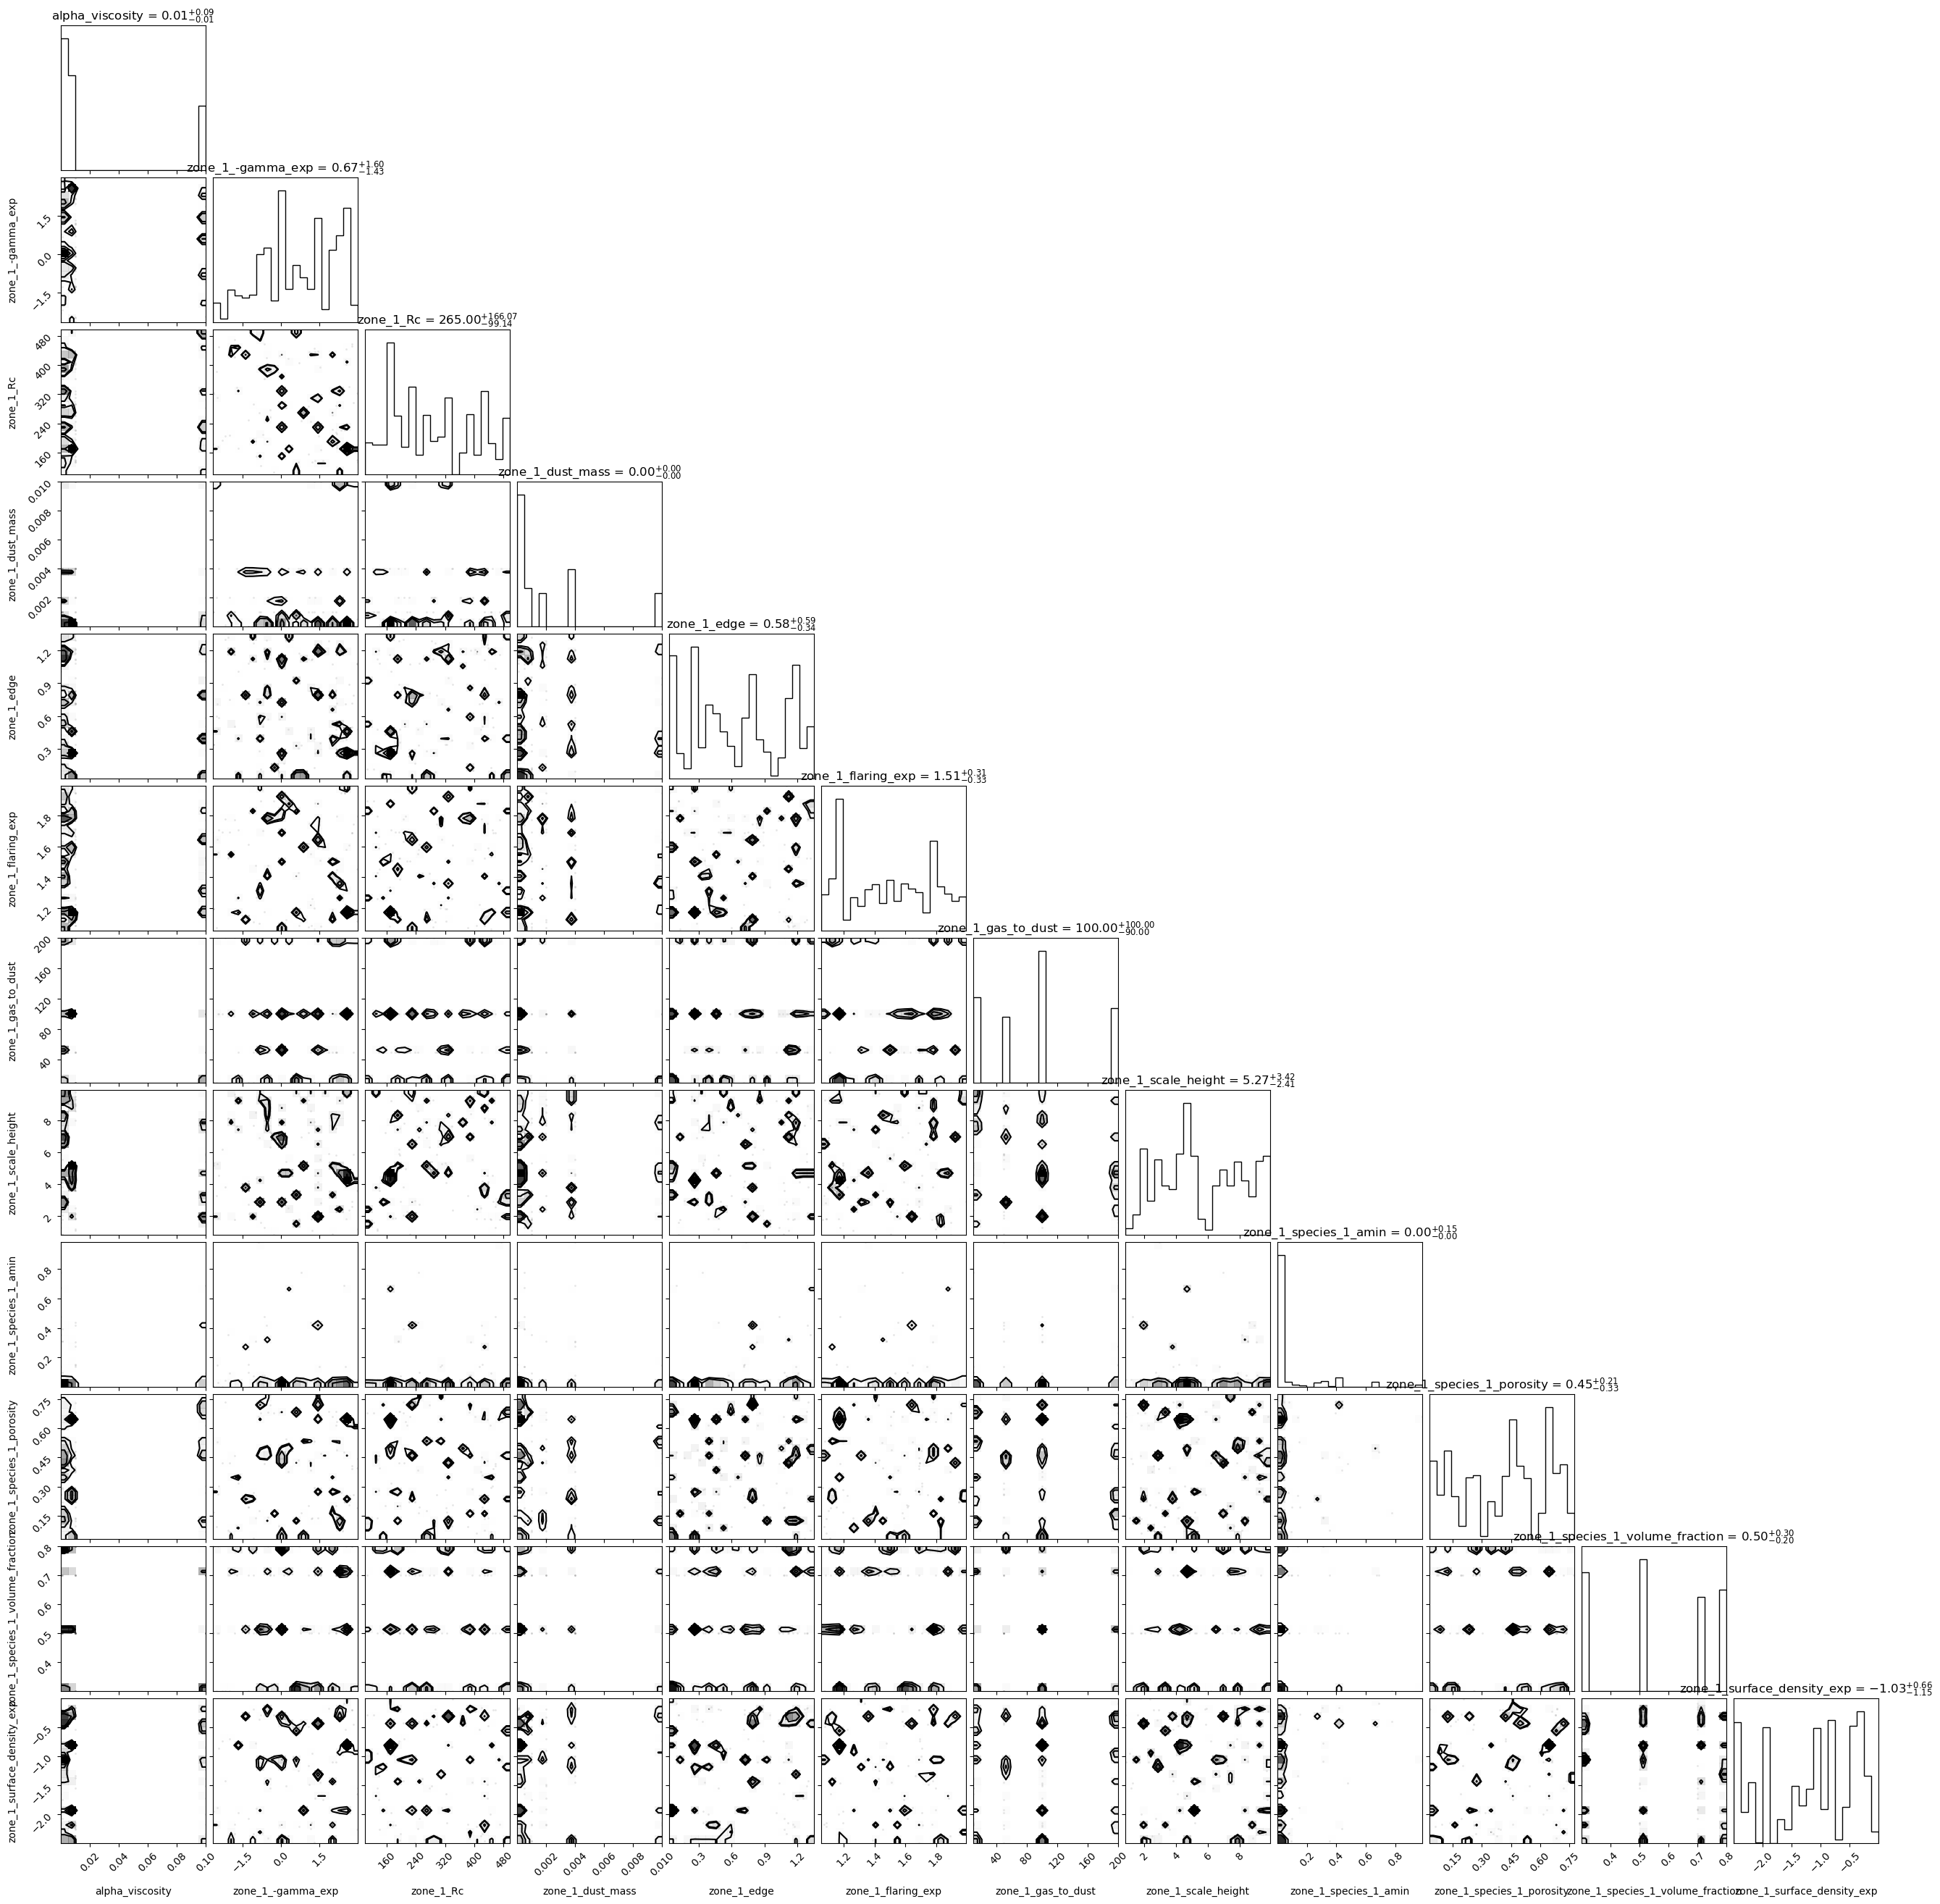

In [24]:
data = df_sel[param_cols].values

fig = corner.corner(
    data,
    labels=param_cols,
    truths=None,              # optional: known reference values
    # quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3g",
    title_kwargs={"fontsize": 10},
)

fig.savefig(results_dir +"corner_all_params.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

weights = 1.0 / df_sel["cost"].values

fig = corner.corner(
    data,
    labels=param_cols,
    weights=weights,
    show_titles=True,
)
fig.savefig(results_dir +"corner_all_params_weighted.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)



In [12]:
#just one function to do it
#WORKS

def make_corner_plot(
    df,
    params,
    *,
    budget=None,
    best_quantile=0.3,
    outfile="corner.png",
):

    d = df.copy()
    if budget is not None:
        d = d[d["budget"] == budget]

    d = d.dropna(subset=["cost"])
    cost_cut = d["cost"].quantile(best_quantile)
    d = d[d["cost"] <= cost_cut]

    data = d[params].values

    fig = corner.corner(
        data,
        labels=params,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".3g",
    )

    fig.savefig(outfile, dpi=150, bbox_inches="tight")
    plt.close(fig)




In [13]:
param_cols=["zone_1_Rc", "zone_1_flaring_exp", "zone_1_dust_mass", "zone_1_species_1_porosity"]
print(df_sel[param_cols].describe())

make_corner_plot(
    df,
    params=param_cols,
    budget=df["budget"].max(),
    outfile=results_dir+ "corner_best.png"
)


        zone_1_Rc  zone_1_flaring_exp  zone_1_dust_mass  \
count  450.000000          450.000000        450.000000   
mean    35.727777            1.280629          0.002062   
std      9.467874            0.141251          0.001145   
min      7.344311            1.002126          0.001000   
25%     32.581723            1.183190          0.001000   
50%     39.396461            1.229243          0.002000   
75%     40.677239            1.415979          0.002000   
max     49.999303            1.596036          0.004000   

       zone_1_species_1_porosity  
count                 450.000000  
mean                    0.323198  
std                     0.173498  
min                     0.005305  
25%                     0.256321  
50%                     0.262164  
75%                     0.352617  
max                     0.794124  


### Test code fro chatgpt, needs to be tested

In [16]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import corner


def runhistory_to_df(smac, cs) -> pd.DataFrame:
    """Convert SMAC runhistory to a flat dataframe with params + metadata."""
    rh = smac.runhistory
    rows = []

    # SMAC RunHistory usually behaves like a dict: key->value
    for key, val in rh.items():
        # key typically has: config_id, seed, budget, instance
        cfg = rh.get_config(key.config_id)
        d = cfg.get_dictionary()

        row = dict(d)
        row["config_id"] = getattr(key, "config_id", None)
        row["seed"] = getattr(key, "seed", None)
        row["budget"] = getattr(key, "budget", None)
        row["instance"] = getattr(key, "instance", None)

        row["cost"] = getattr(val, "cost", None)
        row["time"] = getattr(val, "time", None)
        row["cpu_time"] = getattr(val, "cpu_time", None)
        row["status"] = getattr(val, "status", None)

        # Some SMAC versions store start/end times in val.additional_info
        add = getattr(val, "additional_info", None)
        if isinstance(add, dict):
            row["starttime"] = add.get("starttime", None)
            row["endtime"] = add.get("endtime", None)

        rows.append(row)

    df = pd.DataFrame(rows)

    # Helpful sorting if endtime exists
    if "endtime" in df.columns and df["endtime"].notna().any():
        df = df.sort_values(["endtime", "budget", "cost"], ascending=[True, True, True])
    else:
        df = df.sort_values(["budget", "cost"], ascending=[True, True])

    df = df.reset_index(drop=True)
    return df


def choose_param_columns(df: pd.DataFrame) -> list[str]:
    """Pick all columns that look like model params (exclude SMAC bookkeeping)."""
    exclude = {
        "config_id", "seed", "budget", "instance",
        "cost", "time", "cpu_time", "status",
        "starttime", "endtime",
    }
    return [c for c in df.columns if c not in exclude]


def split_into_groups(params: list[str], max_per_group: int = 10) -> list[list[str]]:
    """Split parameter list into chunks to keep corner readable."""
    if len(params) <= max_per_group:
        return [params]
    groups = []
    for i in range(0, len(params), max_per_group):
        groups.append(params[i:i + max_per_group])
    return groups


def safe_corner(
    df: pd.DataFrame,
    params: list[str],
    outpath: Path,
    *,
    weights: np.ndarray | None = None,
    truths: list[float] | None = None,
    title: str | None = None,
):
    """Make one corner plot robustly, dropping NaNs and constant columns."""
    d = df.copy()

    # Keep only numeric params for corner
    numeric_params = []
    for p in params:
        if p not in d.columns:
            continue
        # coerce to numeric where possible; categorical corner plots are messy
        d[p] = pd.to_numeric(d[p], errors="coerce")
        if d[p].notna().any():
            numeric_params.append(p)

    if len(numeric_params) == 0:
        print(f"[corner] Skip {outpath.name}: no numeric params found.")
        return

    d = d.dropna(subset=numeric_params + ["cost"], how="any")
    if len(d) < 5:
        print(f"[corner] Skip {outpath.name}: too few points ({len(d)}).")
        return

    # Remove constant columns (corner can choke / be useless)
    keep = []
    for p in numeric_params:
        if d[p].nunique(dropna=True) > 1:
            keep.append(p)

    if len(keep) < 2:
        print(f"[corner] Skip {outpath.name}: <2 varying params.")
        return

    data = d[keep].to_numpy(dtype=float)

    # Align truths length if provided
    t = None
    if truths is not None:
        if len(truths) == len(params):
            # Map truths to the kept params
            truth_map = {p: v for p, v in zip(params, truths)}
            t = [truth_map[p] for p in keep]
        elif len(truths) == len(keep):
            t = truths
        else:
            print(f"[corner] Warning: truths length mismatch for {outpath.name}; ignoring truths.")
            t = None

    fig = corner.corner(
        data,
        labels=keep,
        weights=weights,
        truths=t,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        title_fmt=".3g",
        title_kwargs={"fontsize": 10},
    )
    if title:
        fig.suptitle(title, fontsize=12)

    fig.savefig(outpath, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"[corner] Wrote {outpath}")


def main_corner_analysis(smac, cs, results_dir: Path):
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    df = runhistory_to_df(smac, cs)
    df.to_csv(results_dir / "trials.csv", index=False)
    print(f"[analysis] Saved trials table: {results_dir/'trials.csv'}  (N={len(df)})")

    params_all = choose_param_columns(df)
    print(f"[analysis] Detected {len(params_all)} parameter columns.")

    # Prefer max budget for “physical interpretation”
    max_budget = df["budget"].max()
    df_max = df[df["budget"] == max_budget].copy()
    df_max = df_max.dropna(subset=["cost"])
    print(f"[analysis] Max budget = {max_budget} ; N(max-budget)={len(df_max)}")

    # Prepare directories
    corner_dir = results_dir / "corner"
    corner_dir.mkdir(exist_ok=True)

    # If too many params, split into groups
    groups = split_into_groups(params_all, max_per_group=10)

    # ---- 1) Max budget: all points ----
    for gi, grp in enumerate(groups, 1):
        safe_corner(
            df_max,
            grp,
            corner_dir / f"corner_maxbudget_all_group{gi:02d}.png",
            title=f"Max budget ({max_budget}) - all trials - group {gi}",
        )

    # ---- 2) Max budget: best quantile (e.g. best 30%) ----
    best_q = 0.30
    if len(df_max) > 0:
        cut = df_max["cost"].quantile(best_q)
        df_bestq = df_max[df_max["cost"] <= cut].copy()
        print(f"[analysis] Best {int(best_q*100)}% cutoff: cost <= {cut:.6g} ; N={len(df_bestq)}")

        for gi, grp in enumerate(groups, 1):
            safe_corner(
                df_bestq,
                grp,
                corner_dir / f"corner_maxbudget_best{int(best_q*100)}pct_group{gi:02d}.png",
                title=f"Max budget ({max_budget}) - best {int(best_q*100)}% - group {gi}",
            )

    # ---- 3) Max budget: top N ----
    topN = 50
    df_top = df_max.nsmallest(topN, "cost").copy()
    print(f"[analysis] Top {topN} at max budget: N={len(df_top)}")
    for gi, grp in enumerate(groups, 1):
        safe_corner(
            df_top,
            grp,
            corner_dir / f"corner_maxbudget_top{topN}_group{gi:02d}.png",
            title=f"Max budget ({max_budget}) - top {topN} - group {gi}",
        )

    # ---- 4) Weighted by 1/cost (emphasize good models) ----
    # Use best-quantile selection + weights for stability
    if len(df_max) > 0:
        df_w = df_bestq if "df_bestq" in locals() and len(df_bestq) >= 5 else df_max.copy()
        # Avoid divide-by-zero
        w = 1.0 / np.maximum(df_w["cost"].to_numpy(dtype=float), 1e-12)

        for gi, grp in enumerate(groups, 1):
            safe_corner(
                df_w,
                grp,
                corner_dir / f"corner_maxbudget_weighted_group{gi:02d}.png",
                weights=w,
                title=f"Max budget ({max_budget}) - weighted by 1/cost - group {gi}",
            )

    # ---- 5) Per-budget diagnostic corner plots (small groups only) ----
    # These can be a lot; keep only first group by default (edit if you want all groups)
    budgets = sorted(df["budget"].dropna().unique())
    diag_dir = corner_dir / "by_budget"
    diag_dir.mkdir(exist_ok=True)

    # Only do first group by default to avoid 100s of plots
    grp = groups[0] if groups else params_all

    for b in budgets:
        df_b = df[df["budget"] == b].dropna(subset=["cost"]).copy()
        if len(df_b) < 10:
            continue
        safe_corner(
            df_b,
            grp,
            diag_dir / f"corner_budget_{b:g}.png",
            title=f"Budget {b:g} - diagnostics (group 1)",
        )

    # ---- Extra: save “trajectory” (best-so-far) table ----
    # Compute best-so-far ordering by time if available, otherwise row order
    if "endtime" in df.columns and df["endtime"].notna().any():
        df_ord = df.sort_values("endtime").copy()
    else:
        df_ord = df.copy()

    best_cost = np.inf
    keep_idx = []
    for i, row in df_ord.iterrows():
        if row["cost"] < best_cost:
            best_cost = row["cost"]
            keep_idx.append(i)

    traj_df = df_ord.loc[keep_idx].reset_index(drop=True)
    traj_df.to_csv(results_dir / "trajectory_best_so_far.csv", index=False)
    print(f"[analysis] Saved trajectory: {results_dir/'trajectory_best_so_far.csv'}  (K={len(traj_df)})")

    # Save some quick summaries
    (df.groupby("budget")["cost"].describe()
       .to_csv(results_dir / "cost_by_budget.csv"))
    print(f"[analysis] Saved cost summary: {results_dir/'cost_by_budget.csv'}")


# ---- call it ----
# Use results_dir you already created; I suggest putting plots under results_dir
main_corner_analysis(smac, cs, results_dir)


NameError: name 'smac' is not defined